In [34]:
import sys 
sys.path.append("../..")

In [36]:
import pandas as pd

from matplotlib import pyplot as plt 

from pathlib import Path
import numpy as np 

from xaikd import models, datasets
from xaikd.utils import metrics

In [5]:
DATA_DIR = Path("../../artifacts/2023-06-s8/quantify-variance-bias")

In [17]:
def load_data(model, dataset, layer, mode, num_samples, seed=1):
    
    return pd.read_csv(DATA_DIR / f"{dataset}-seed{seed}" / f"{model}--layer-{layer}--mode-{mode}--n{num_samples}" / "stats.csv")

load_data("cifar100-resnet18-p1", "cifar100-people", "layer3", "homogenous", 50)

,Unnamed: 0,train_acc,val_acc
0,0,0.284,0.230
1,1,0.316,0.272
2,2,0.240,0.218
3,3,0.284,0.230
4,4,0.452,0.262
5,5,0.608,0.324
6,6,0.732,0.356
7,7,0.780,0.378
8,8,0.896,0.392
9,9,0.912,0.394


In [40]:
ACCURACY_CACHE = dict()

def get_accuracy(arch, dataset):
    
    
    key = f"{arch}-{dataset}"
    
    if key in ACCURACY_CACHE:
        return ACCURACY_CACHE[key]
    
    
    
    
    model = models.get_model(arch)
    ds = datasets.construct(dataset)
    
    val_dl = ds.loader(train_split=False)
    
    acc = metrics.accuracy_with_subclasses(
        model, 
        val_dl,
        ds.selected_classes,
        ds.transform_target,
        device="cpu"
    )
    
    ACCURACY_CACHE[key] = acc
    
    return get_accuracy(arch, dataset)
    
get_accuracy("cifar100-resnet18-p1", "cifar100-people")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


0.550000011920929

[0.248      0.46000001 0.54799998 0.61400002]
[0.30399999 0.49399999 0.56599998 0.602     ]


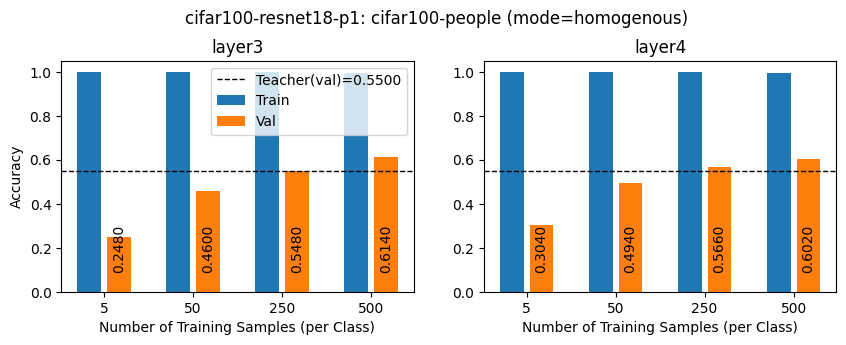

In [59]:
def viz(mode):
    
    arch = "cifar100-resnet18-p1"
    dataset = "cifar100-people"
    arr_ns = [5, 50, 250, 500]
    layers = ["layer3", "layer4"]
    seed = 1
    
    ncols = len(layers)
    
    plt.figure(figsize=(5*ncols, 3))
    plt.suptitle(f"{arch}: {dataset} (mode={mode})", y=1.05)
    
    ticks = np.arange(len(arr_ns)) * 3
    
    teacher_acc = get_accuracy(arch, dataset)
    
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        
        stats = np.zeros((len(arr_ns), 2))
        
        
        for nix, n in enumerate(arr_ns):
            df = load_data(model=arch, dataset=dataset, layer=layer, mode=mode, num_samples=n, seed=seed)
            
            stats[nix, :] = df["train_acc"].max(), df["val_acc"].max()
            
        plt.bar(ticks, stats[:, 0], label="Train")
        plt.bar(ticks+1, stats[:, 1], label="Val")
        
        print(stats[:, 1])
        
        for i, t in enumerate(ticks + 1):
            plt.text(t, 0.1, f"{stats[i, 1]:.4f}", rotation=90, ha="center")
    
        plt.xticks(ticks+0.5, arr_ns)
        
        plt.xlabel("Number of Training Samples (per Class)")
        plt.axhline(teacher_acc, ls="--", lw=1, color="k", label=f"Teacher(val)={teacher_acc:.4f}")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()
viz(mode="homogenous")

[0.27599999 0.456      0.54400003 0.60600001]
[0.33399999 0.5        0.56599998 0.59399998]


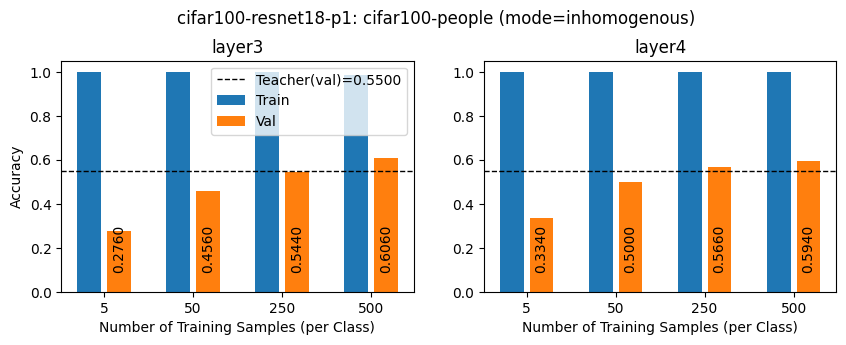

In [60]:
viz(mode="inhomogenous")